# Options Pricing Simulator Demo

This notebook demonstrates the functionality of the Options Pricing Simulator, showcasing various pricing models, Greeks calculations, and visualization capabilities.

## Setup and Imports

In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to path to import our modules
# Get the absolute path to the notebook directory
notebook_dir = os.path.abspath('')
# Navigate up one level to the project root directory
project_root = os.path.dirname(notebook_dir)
# Add the project root to sys.path
sys.path.append(project_root)

# Import our modules
from pricing.black_scholes import black_scholes_price, implied_volatility
from pricing.binomial_tree import binomial_tree_price, trinomial_tree_price
from pricing.greeks import calculate_all_greeks
from app.visuals import (
    plot_option_price_vs_underlying,
    plot_option_price_surface,
    plot_greek_surface,
    plot_greeks_vs_underlying,
    plot_option_payoff,
    plot_strategy_payoff
)

# Define custom color scheme
MINT = "#ddffe7"
SPEARMINT = "#98d7c2"
TEAL_GREEN = "#167d7f"
TEAL = "#29a0b1"

# Set custom theme for matplotlib
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[TEAL, TEAL_GREEN, SPEARMINT, MINT])
plt.rcParams['figure.facecolor'] = MINT
plt.rcParams['axes.facecolor'] = MINT
plt.rcParams['axes.edgecolor'] = TEAL_GREEN
plt.rcParams['axes.labelcolor'] = TEAL_GREEN
plt.rcParams['xtick.color'] = TEAL_GREEN
plt.rcParams['ytick.color'] = TEAL_GREEN
plt.rcParams['grid.color'] = SPEARMINT
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

# Set Seaborn theme with custom palette
sns.set_theme(style="whitegrid")
custom_palette = [TEAL, TEAL_GREEN, SPEARMINT, MINT]
sns.set_palette(custom_palette)

## 1. Black-Scholes Option Pricing

Let's start by pricing a European call option using the Black-Scholes model.

In [2]:
# Define option parameters
S = 100.0  # Underlying price
K = 100.0  # Strike price
T = 1.0    # Time to maturity in years
r = 0.05   # Risk-free rate
sigma = 0.20  # Volatility
option_type = 'call'

# Calculate option price
price = black_scholes_price(S, K, T, r, sigma, option_type)

print(f"Black-Scholes price for a {option_type} option:")
print(f"Underlying price: ${S}")
print(f"Strike price: ${K}")
print(f"Time to maturity: {T} year(s)")
print(f"Risk-free rate: {r*100}%")
print(f"Volatility: {sigma*100}%")
print(f"Option price: ${price:.4f}")

Black-Scholes price for a call option:
Underlying price: $100.0
Strike price: $100.0
Time to maturity: 1.0 year(s)
Risk-free rate: 5.0%
Volatility: 20.0%
Option price: $10.4506


### Compare Price for Both Call and Put Options

In [3]:
# Calculate prices for both option types
call_price = black_scholes_price(S, K, T, r, sigma, 'call')
put_price = black_scholes_price(S, K, T, r, sigma, 'put')

# Create a DataFrame to display the results
df = pd.DataFrame({
    'Option Type': ['Call', 'Put'],
    'Price': [call_price, put_price]
})

# Check put-call parity: call - put = S - K*e^(-rT)
parity_value = S - K * np.exp(-r * T)
df['Put-Call Parity'] = [call_price - put_price, parity_value]

df

,Option Type,Price,Put-Call Parity
0,Call,10.450584,4.877058
1,Put,5.573526,4.877058


## 2. Visualizing Option Price vs. Underlying Price

Let's visualize how the option price changes with the underlying price.

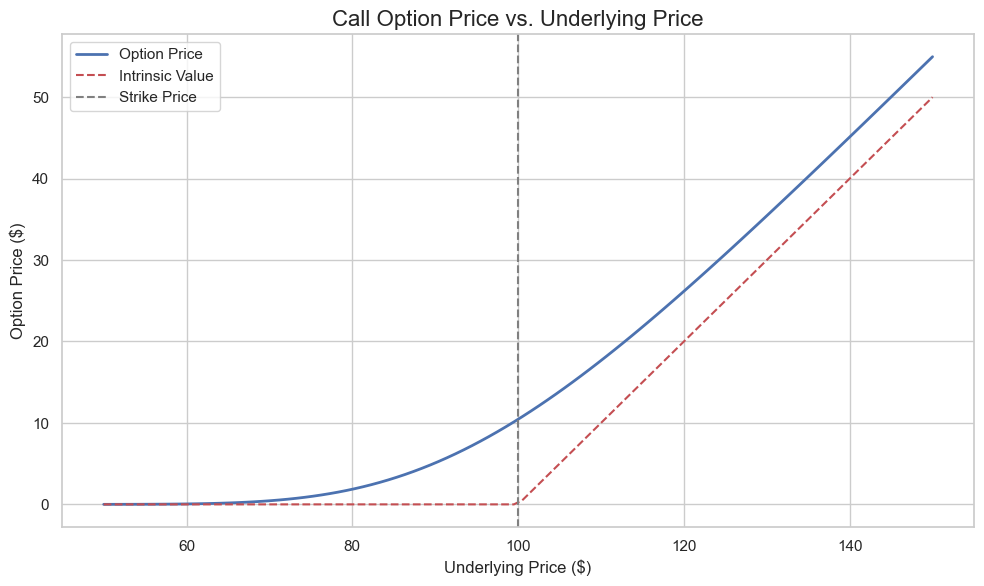

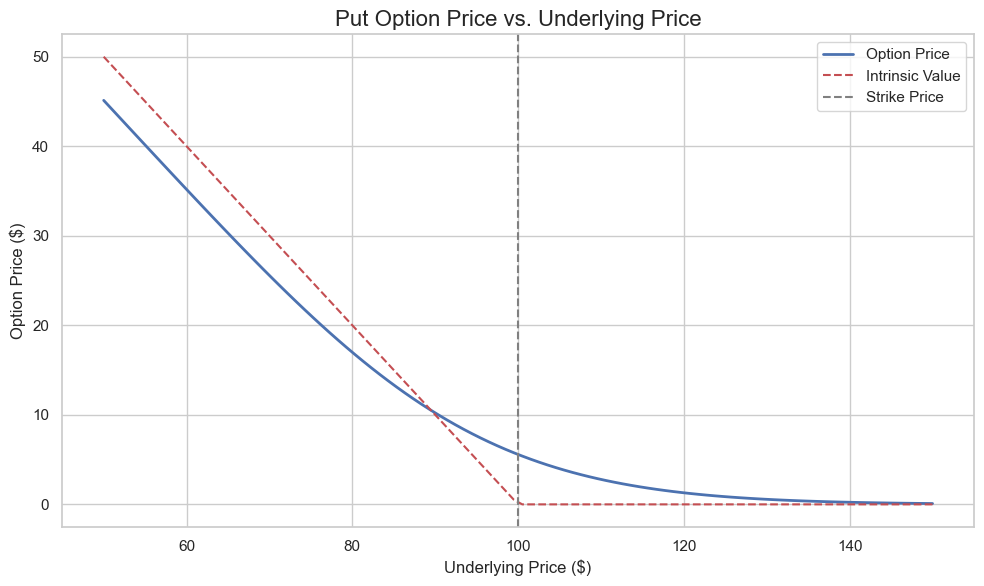

In [4]:
# Create a range of underlying prices
S_range = np.linspace(50, 150, 100)

# Plot call option price
call_fig = plot_option_price_vs_underlying(S_range, K, T, r, sigma, 'call')
plt.title('Call Option Price vs. Underlying Price', fontsize=16)
plt.show()

# Plot put option price
put_fig = plot_option_price_vs_underlying(S_range, K, T, r, sigma, 'put')
plt.title('Put Option Price vs. Underlying Price', fontsize=16)
plt.show()

## 3. Comparing Option Pricing Models

Let's compare the Black-Scholes model with the Binomial and Trinomial tree models.

In [5]:
# Set parameters
S = 100.0
K = 100.0
T = 1.0
r = 0.05
sigma = 0.20
option_type = 'call'
option_style = 'european'  # Can be 'european' or 'american'
n_steps = 100

# Calculate prices using different models
bs_price = black_scholes_price(S, K, T, r, sigma, option_type)
binomial_price = binomial_tree_price(S, K, T, r, sigma, option_type, option_style, n_steps)
trinomial_price = trinomial_tree_price(S, K, T, r, sigma, option_type, option_style, n_steps//2)

# Create a DataFrame to display the results
models_df = pd.DataFrame({
    'Model': ['Black-Scholes', 'Binomial Tree', 'Trinomial Tree'],
    'Price': [bs_price, binomial_price, trinomial_price],
    'Difference from BS': [0, binomial_price - bs_price, trinomial_price - bs_price]
})

models_df

,Model,Price,Difference from BS
0,Black-Scholes,1.045058e+01,0.000000
1,Binomial Tree,1.043061e+01,-0.019972
2,Trinomial Tree,3.242580e-29,-10.450584


### Convergence of Tree Models

Let's examine how the tree models converge to the Black-Scholes price as the number of steps increases.

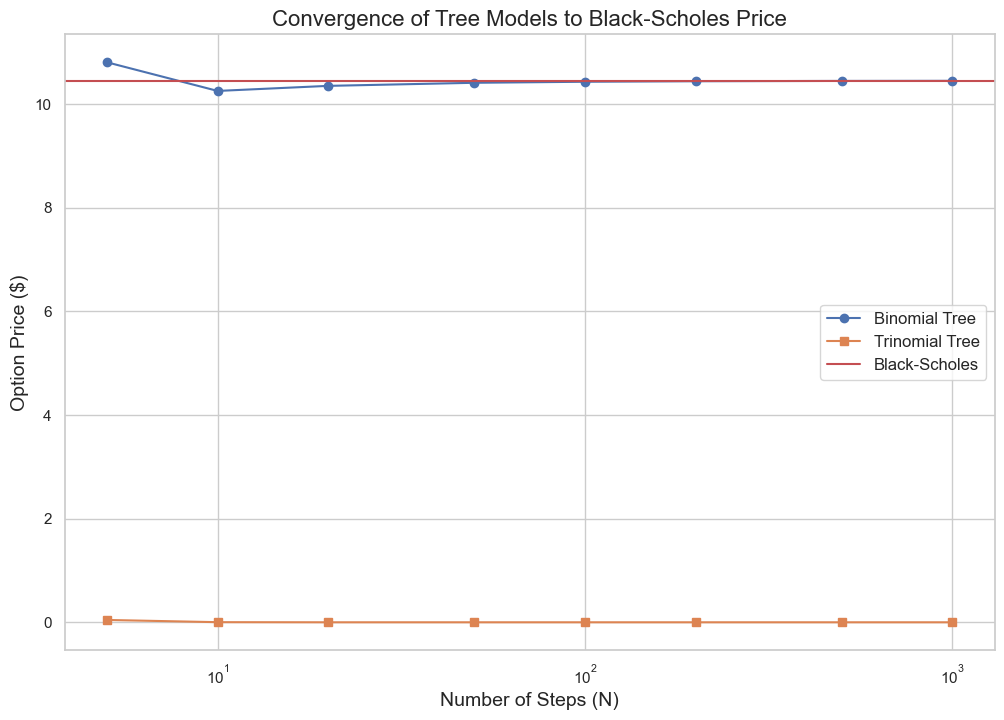

In [6]:
# Define a range of steps
step_range = np.array([5, 10, 20, 50, 100, 200, 500, 1000])

# Calculate option prices for different numbers of steps
binomial_prices = []
trinomial_prices = []

for n in step_range:
    binomial_prices.append(binomial_tree_price(S, K, T, r, sigma, option_type, option_style, n))
    trinomial_prices.append(trinomial_tree_price(S, K, T, r, sigma, option_type, option_style, n//2))

# Plot convergence
plt.figure(figsize=(12, 8))
plt.plot(step_range, binomial_prices, 'o-', label='Binomial Tree')
plt.plot(step_range, trinomial_prices, 's-', label='Trinomial Tree')
plt.axhline(y=bs_price, color='r', linestyle='-', label='Black-Scholes')

plt.xscale('log')
plt.title('Convergence of Tree Models to Black-Scholes Price', fontsize=16)
plt.xlabel('Number of Steps (N)', fontsize=14)
plt.ylabel('Option Price ($)', fontsize=14)
plt.grid(True)
plt.legend(fontsize=12)
plt.show()

## 4. Option Greeks Calculation

Let's calculate and display the option Greeks for the given parameters.

In [7]:
# Calculate Greeks for call and put options
call_greeks = calculate_all_greeks(S, K, T, r, sigma, 'call')
put_greeks = calculate_all_greeks(S, K, T, r, sigma, 'put')

# Create a DataFrame to display the results
greeks_df = pd.DataFrame({
    'Call Option': call_greeks,
    'Put Option': put_greeks
})

greeks_df

,Call Option,Put Option
delta,0.636831,-0.363169
gamma,0.018762,0.018762
theta,-6.414028,-1.657880
vega,0.375240,0.375240
rho,0.532325,-0.418905


### Visualizing Option Greeks

Let's visualize how the Greeks change with the underlying price.

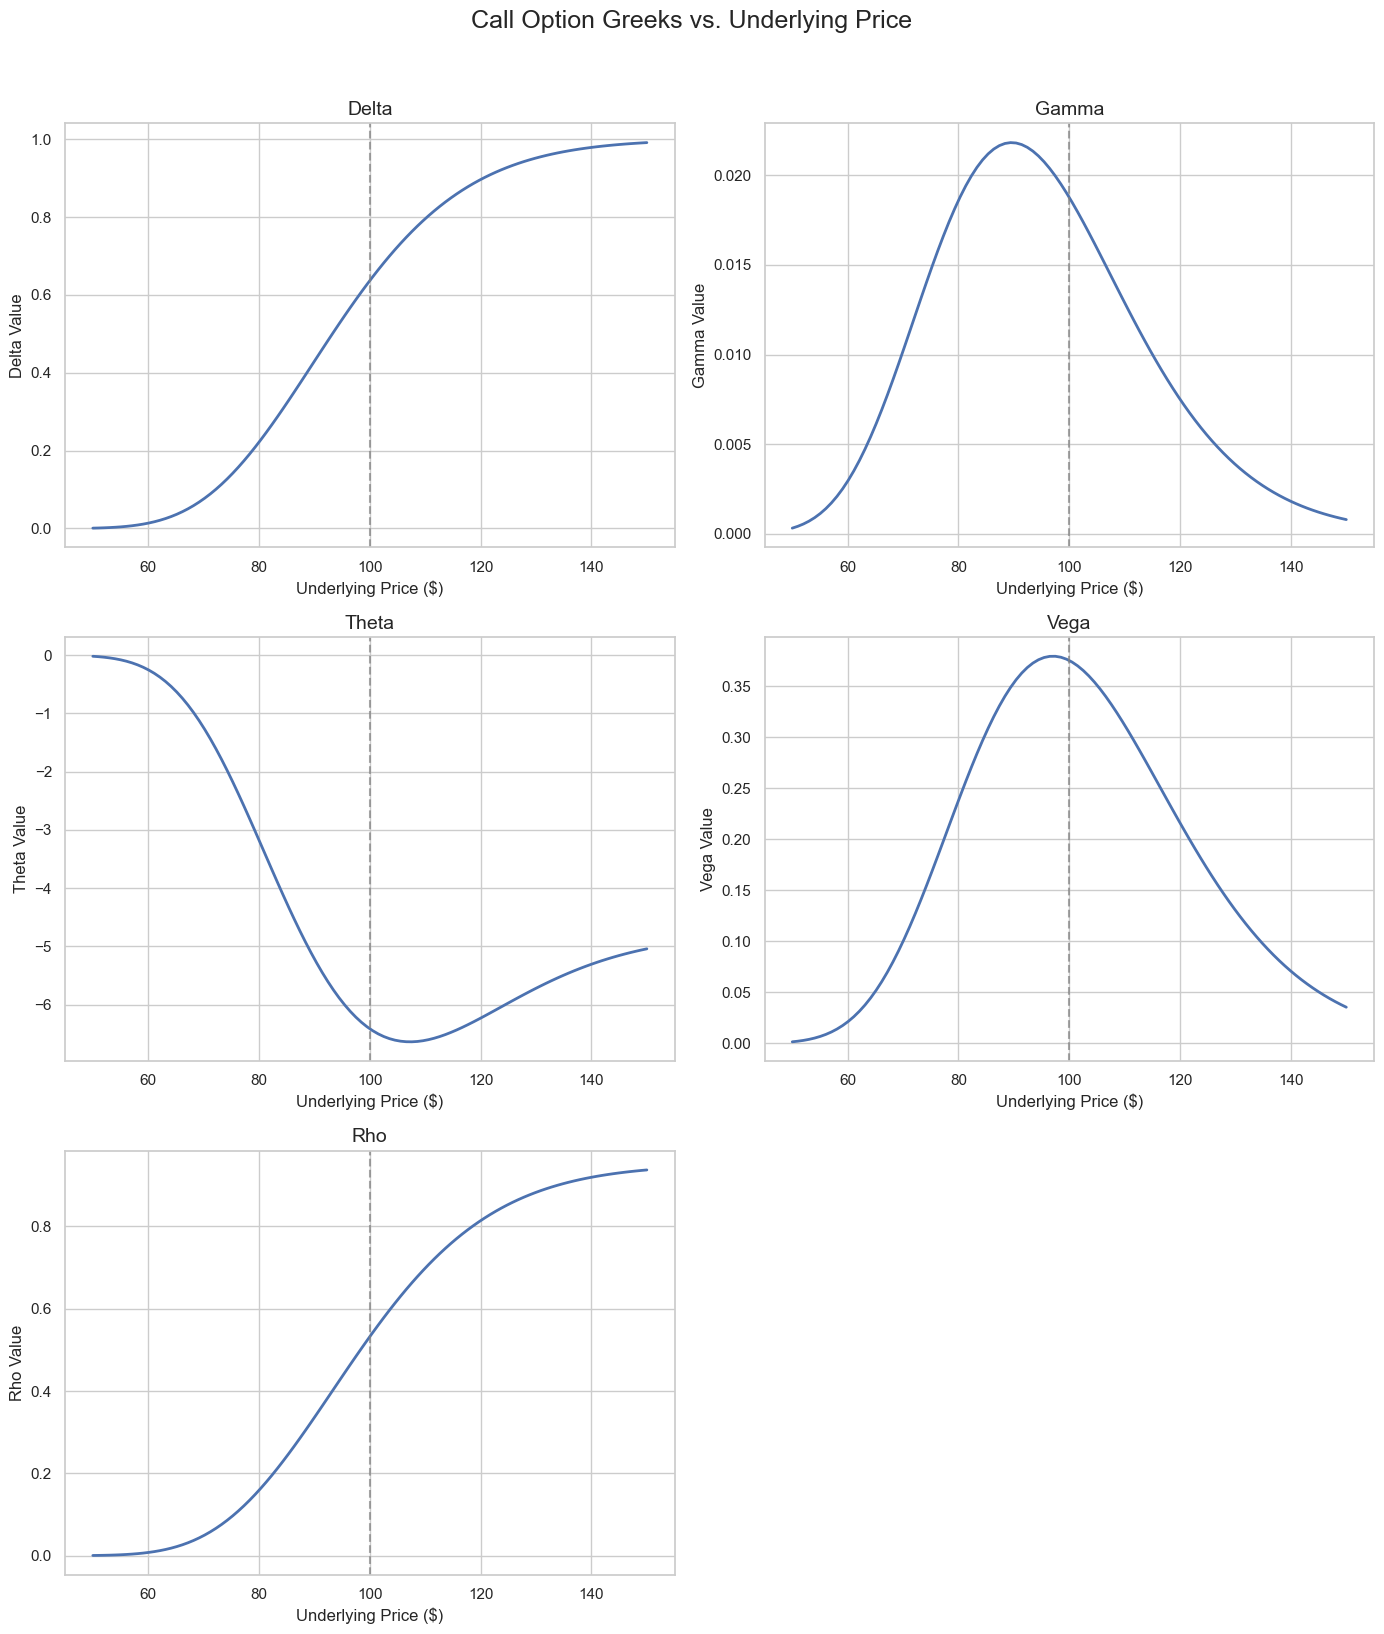

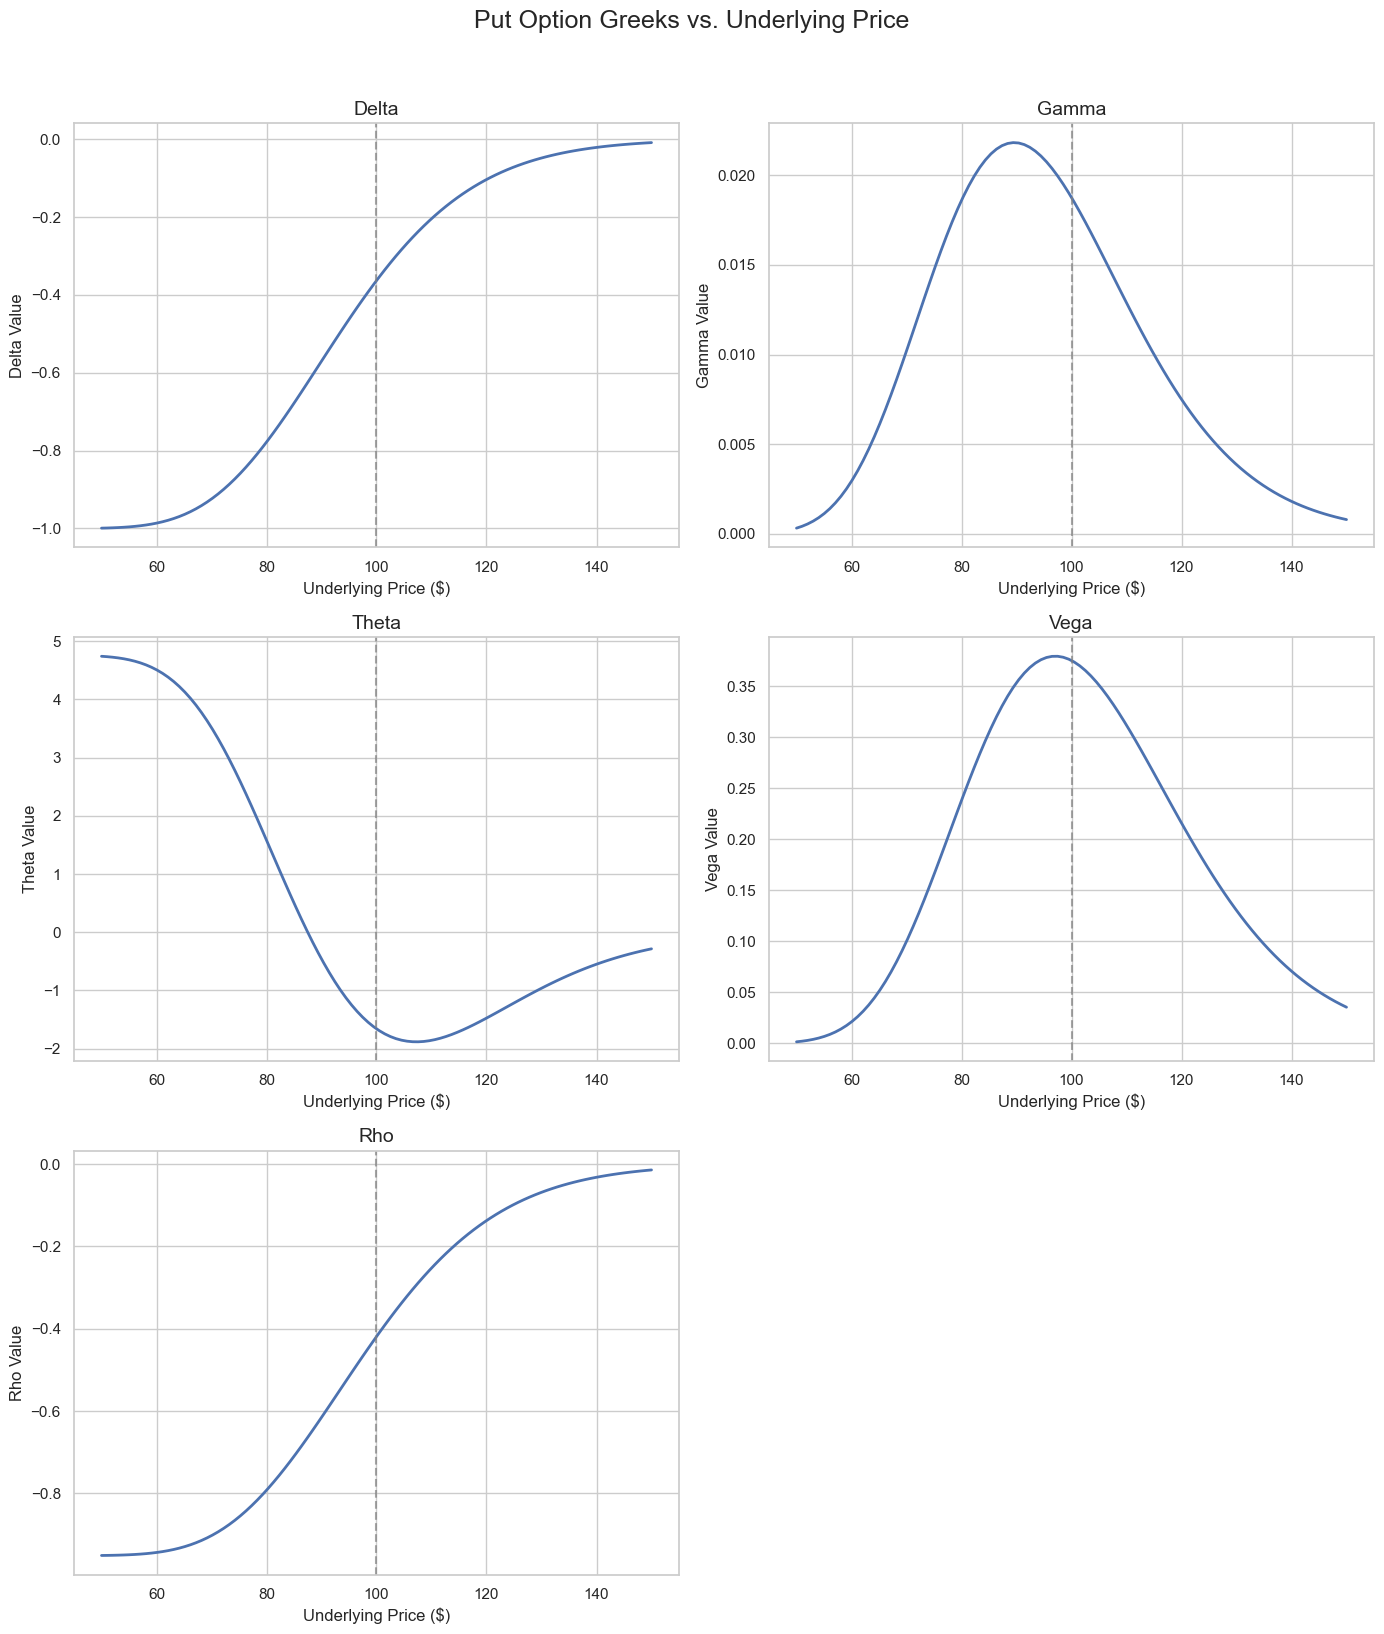

In [8]:
# Create a range of underlying prices
S_range = np.linspace(50, 150, 100)

# Plot all Greeks for call option
call_greeks_fig = plot_greeks_vs_underlying(S_range, K, T, r, sigma, 'call')
plt.suptitle('Call Option Greeks vs. Underlying Price', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# Plot all Greeks for put option
put_greeks_fig = plot_greeks_vs_underlying(S_range, K, T, r, sigma, 'put')
plt.suptitle('Put Option Greeks vs. Underlying Price', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

## 5. Option Price Surface

Let's create a 3D surface plot showing how the option price changes with both underlying price and time to maturity.

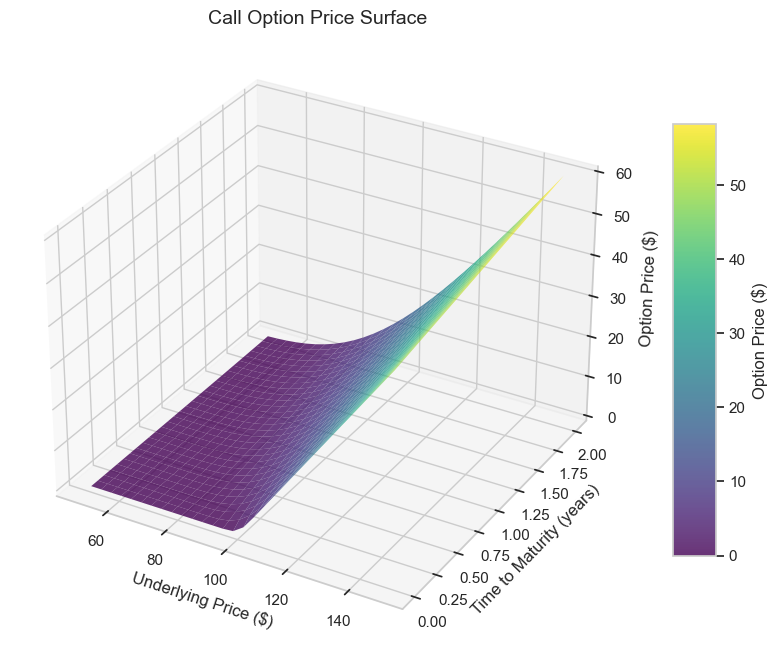

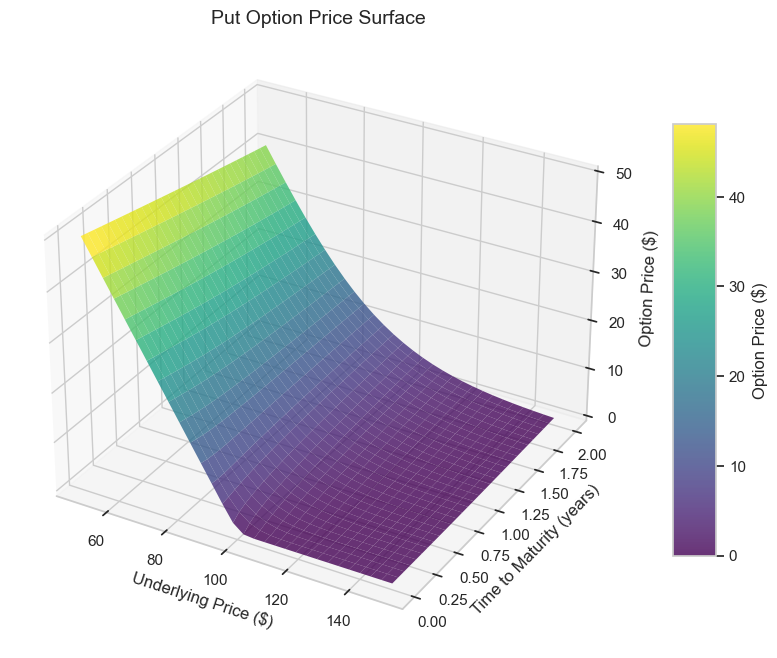

In [9]:
# Define ranges for underlying price and time to maturity
S_range = np.linspace(50, 150, 30)
T_range = np.linspace(0.01, 2.0, 30)  # Avoid T=0 to prevent division by zero

# Create and display the surface plot for call option
call_surface_fig = plot_option_price_surface(S_range, T_range, K, r, sigma, 'call')
plt.show()

# Create and display the surface plot for put option
put_surface_fig = plot_option_price_surface(S_range, T_range, K, r, sigma, 'put')
plt.show()

## 6. Greek Surface Visualization

Let's visualize how Delta changes with underlying price and time to maturity.

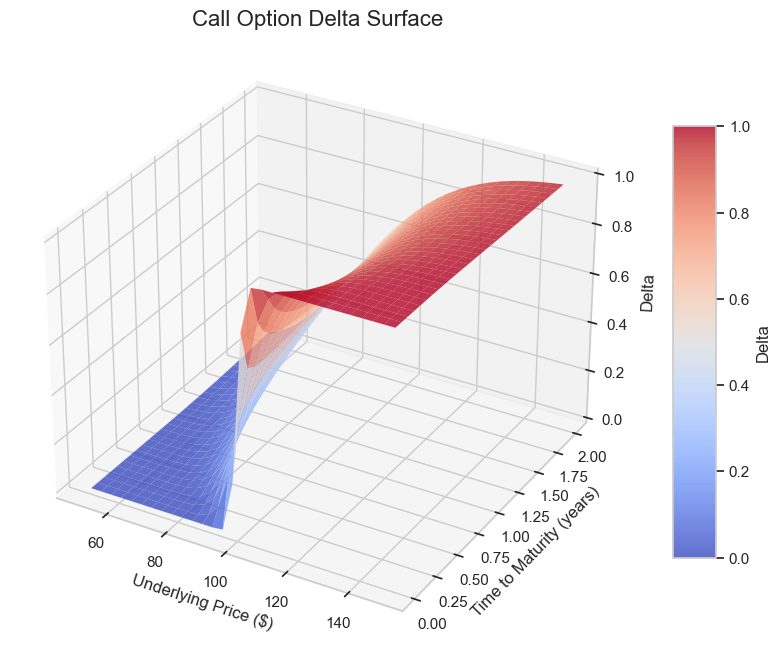

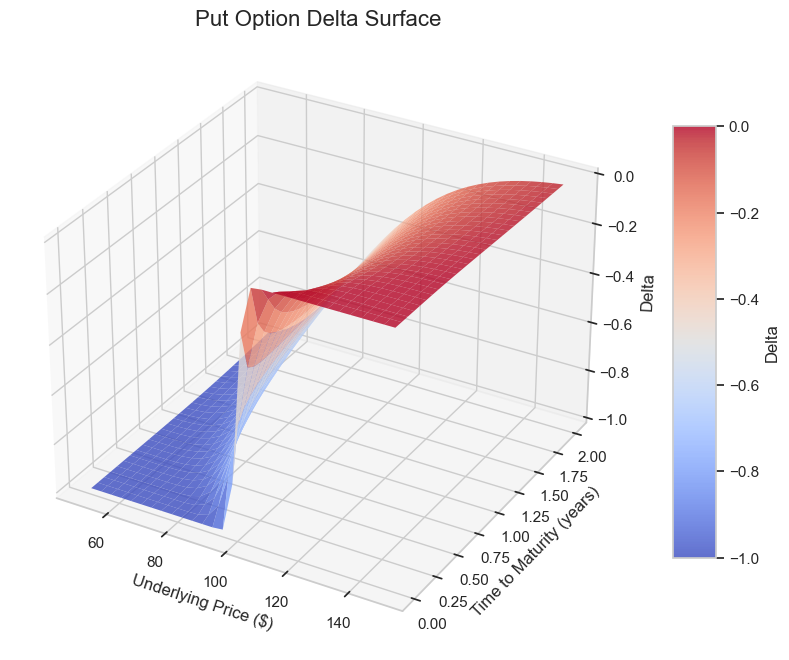

In [10]:
# Create surface plots for call option Delta
call_delta_fig = plot_greek_surface(S_range, T_range, K, r, sigma, 'delta', 'call')
plt.title('Call Option Delta Surface', fontsize=16)
plt.show()

# Create surface plots for put option Delta
put_delta_fig = plot_greek_surface(S_range, T_range, K, r, sigma, 'delta', 'put')
plt.title('Put Option Delta Surface', fontsize=16)
plt.show()

## 7. Option Strategies and Payoffs

Let's analyze some common option strategies.

### 7.1 Long Call vs. Long Put

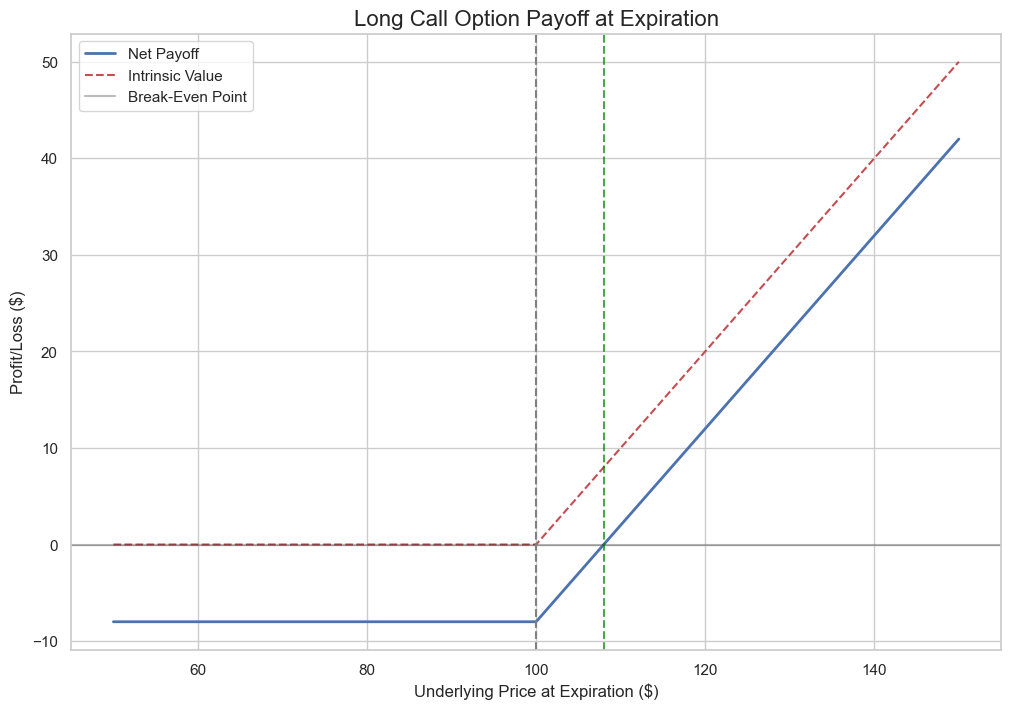

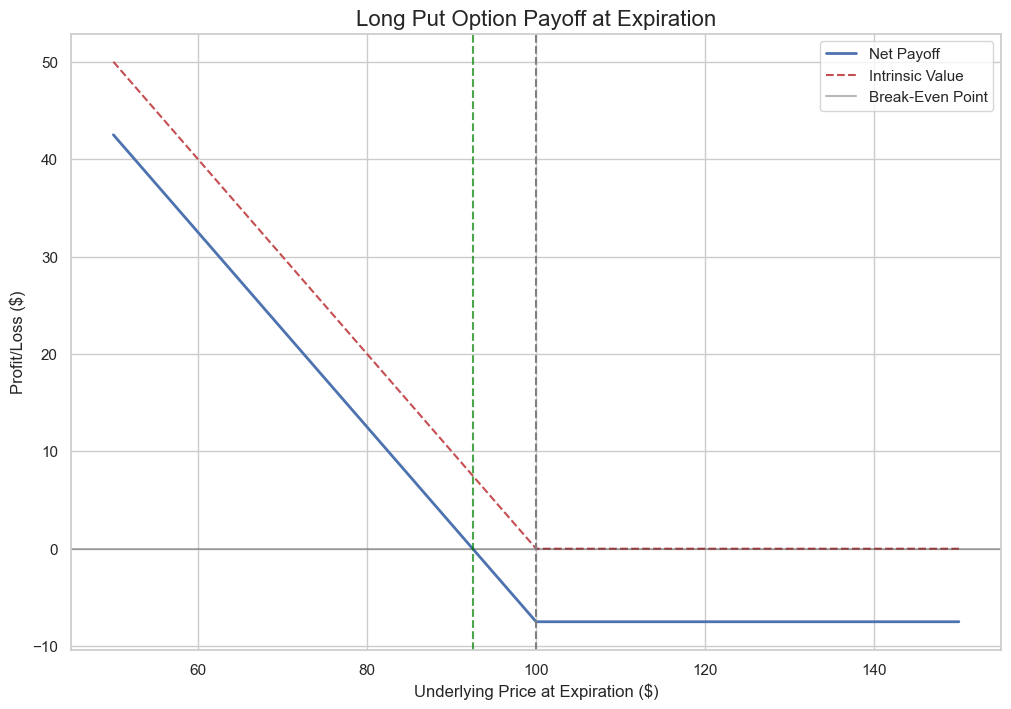

In [11]:
# Set parameters
S = 100.0
K = 100.0
premium_call = 8.0
premium_put = 7.5

# Create underlying price range for analysis
S_range = np.linspace(50, 150, 1000)

# Plot payoff diagram for a long call
fig, ax = plt.subplots(figsize=(12, 8))
ax = plot_option_payoff(S_range, K, premium_call, 'call', 1, ax)
ax.set_title('Long Call Option Payoff at Expiration', fontsize=16)
plt.show()

# Plot payoff diagram for a long put
fig, ax = plt.subplots(figsize=(12, 8))
ax = plot_option_payoff(S_range, K, premium_put, 'put', 1, ax)
ax.set_title('Long Put Option Payoff at Expiration', fontsize=16)
plt.show()

### 7.2 Bull Call Spread

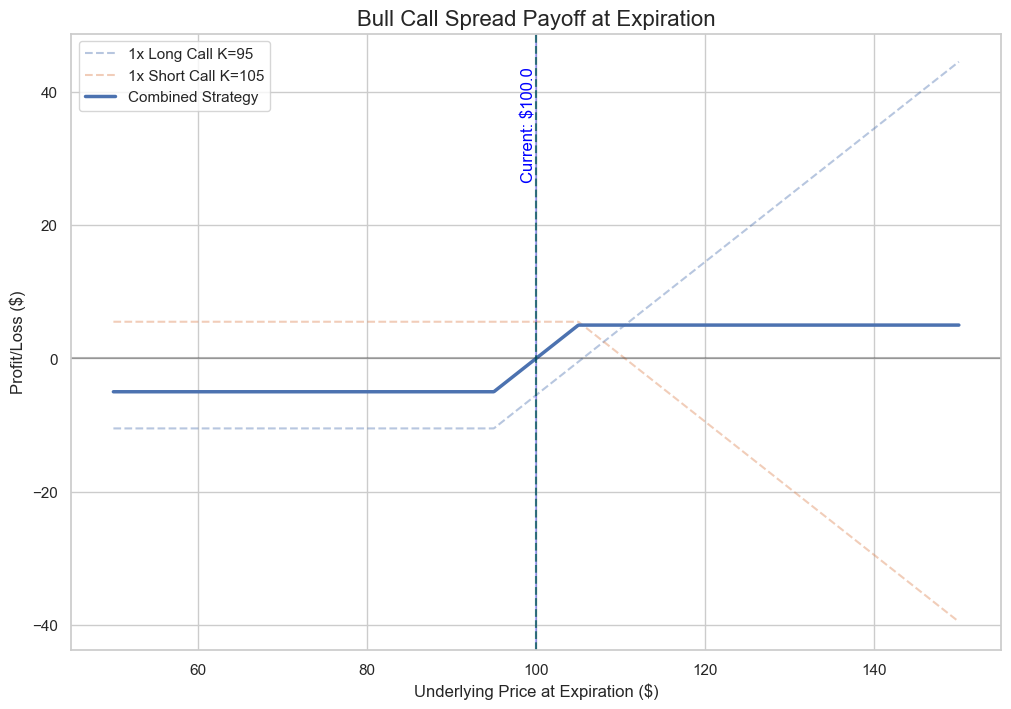

In [12]:
# Define a bull call spread strategy
bull_call_spread = [
    {"type": "call", "strike": 95, "premium": 10.5, "quantity": 1},   # Long lower strike call
    {"type": "call", "strike": 105, "premium": 5.5, "quantity": -1}   # Short higher strike call
]

# Plot the strategy payoff
fig, ax = plt.subplots(figsize=(12, 8))
ax = plot_strategy_payoff(bull_call_spread, S_range, ax)
ax.set_title('Bull Call Spread Payoff at Expiration', fontsize=16)

# Add vertical line at current price
ax.axvline(x=S, color='blue', linestyle='-', alpha=0.3)
ax.text(S, ax.get_ylim()[1]*0.9, f"Current: ${S}", rotation=90, 
        ha='right', va='top', color='blue', fontsize=12)

plt.show()

### 7.3 Long Straddle

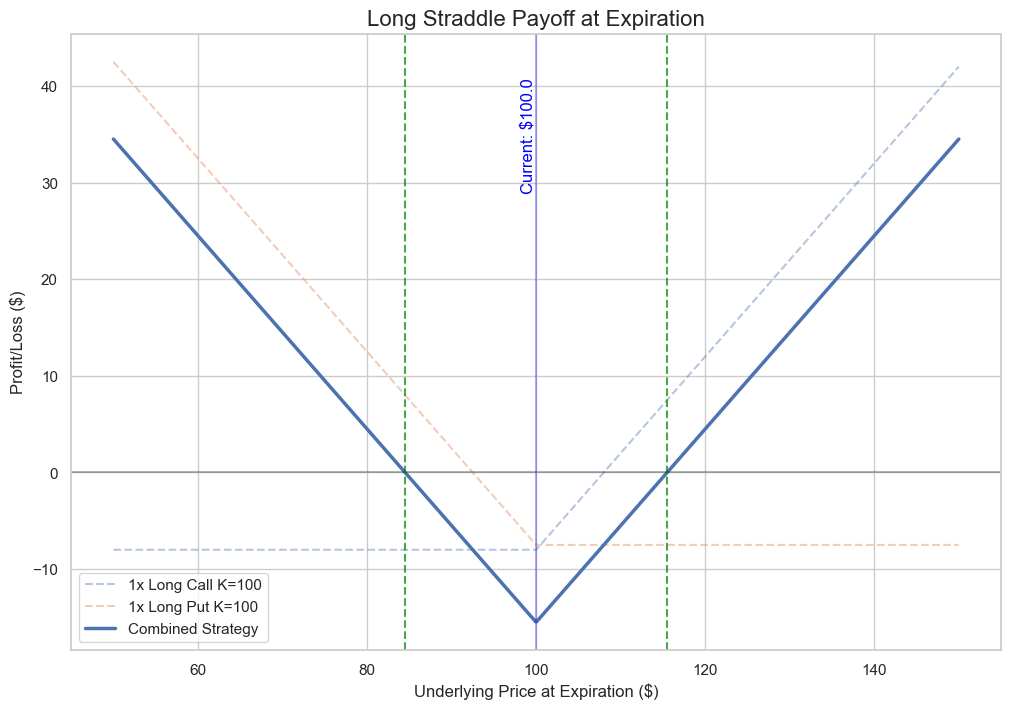

In [13]:
# Define a long straddle strategy (long call + long put at same strike)
long_straddle = [
    {"type": "call", "strike": 100, "premium": 8.0, "quantity": 1},
    {"type": "put", "strike": 100, "premium": 7.5, "quantity": 1}
]

# Plot the strategy payoff
fig, ax = plt.subplots(figsize=(12, 8))
ax = plot_strategy_payoff(long_straddle, S_range, ax)
ax.set_title('Long Straddle Payoff at Expiration', fontsize=16)

# Add vertical line at current price
ax.axvline(x=S, color='blue', linestyle='-', alpha=0.3)
ax.text(S, ax.get_ylim()[1]*0.9, f"Current: ${S}", rotation=90, 
        ha='right', va='top', color='blue', fontsize=12)

plt.show()

### 7.4 Iron Condor

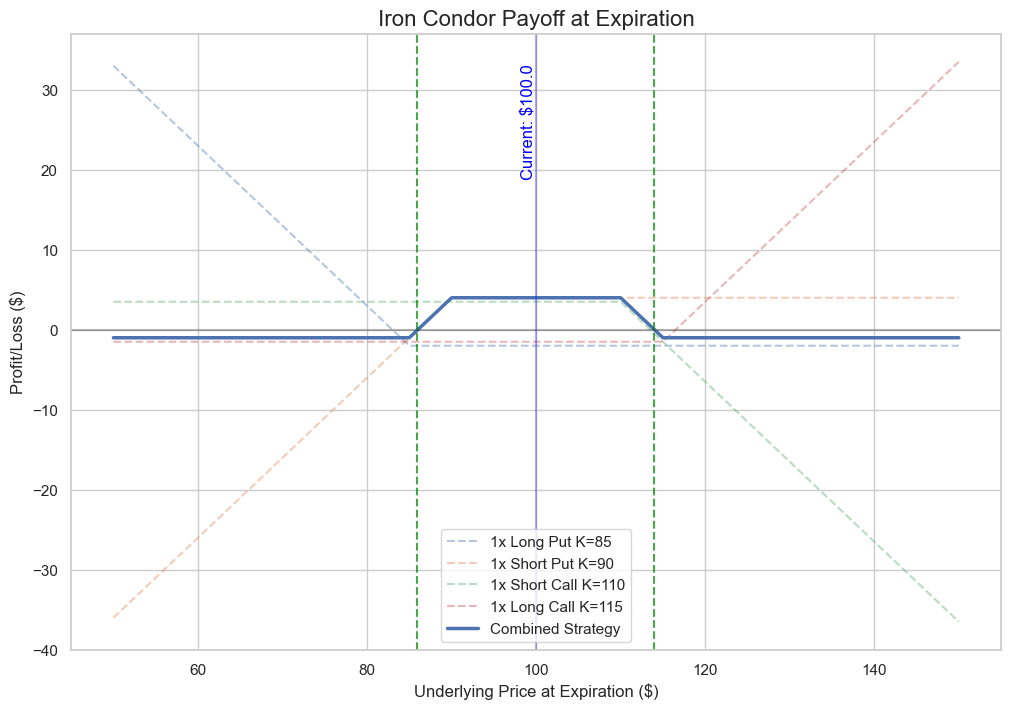

In [14]:
# Define an iron condor strategy
iron_condor = [
    {"type": "put", "strike": 85, "premium": 2.0, "quantity": 1},    # Long OTM put
    {"type": "put", "strike": 90, "premium": 4.0, "quantity": -1},   # Short OTM put
    {"type": "call", "strike": 110, "premium": 3.5, "quantity": -1},  # Short OTM call
    {"type": "call", "strike": 115, "premium": 1.5, "quantity": 1}    # Long OTM call
]

# Plot the strategy payoff
fig, ax = plt.subplots(figsize=(12, 8))
ax = plot_strategy_payoff(iron_condor, S_range, ax)
ax.set_title('Iron Condor Payoff at Expiration', fontsize=16)

# Add vertical line at current price
ax.axvline(x=S, color='blue', linestyle='-', alpha=0.3)
ax.text(S, ax.get_ylim()[1]*0.9, f"Current: ${S}", rotation=90, 
        ha='right', va='top', color='blue', fontsize=12)

plt.show()

## 8. Implied Volatility Calculation

Let's calculate implied volatility from market prices.

In [15]:
# Define the parameters
S = 100.0
K = 100.0
T = 1.0
r = 0.05
true_sigma = 0.25  # The "true" volatility we'll use to generate market prices

# Generate a "market" price using the true_sigma
market_price = black_scholes_price(S, K, T, r, true_sigma, 'call')

# Calculate implied volatility from the market price
implied_vol = implied_volatility(market_price, S, K, T, r, 'call')

print(f"Option Market Price: ${market_price:.4f}")
print(f"True Volatility: {true_sigma*100:.2f}%")
print(f"Implied Volatility: {implied_vol*100:.2f}%")

Option Market Price: $12.3360
True Volatility: 25.00%
Implied Volatility: 25.00%


### Implied Volatility Smile

Let's simulate an implied volatility smile.

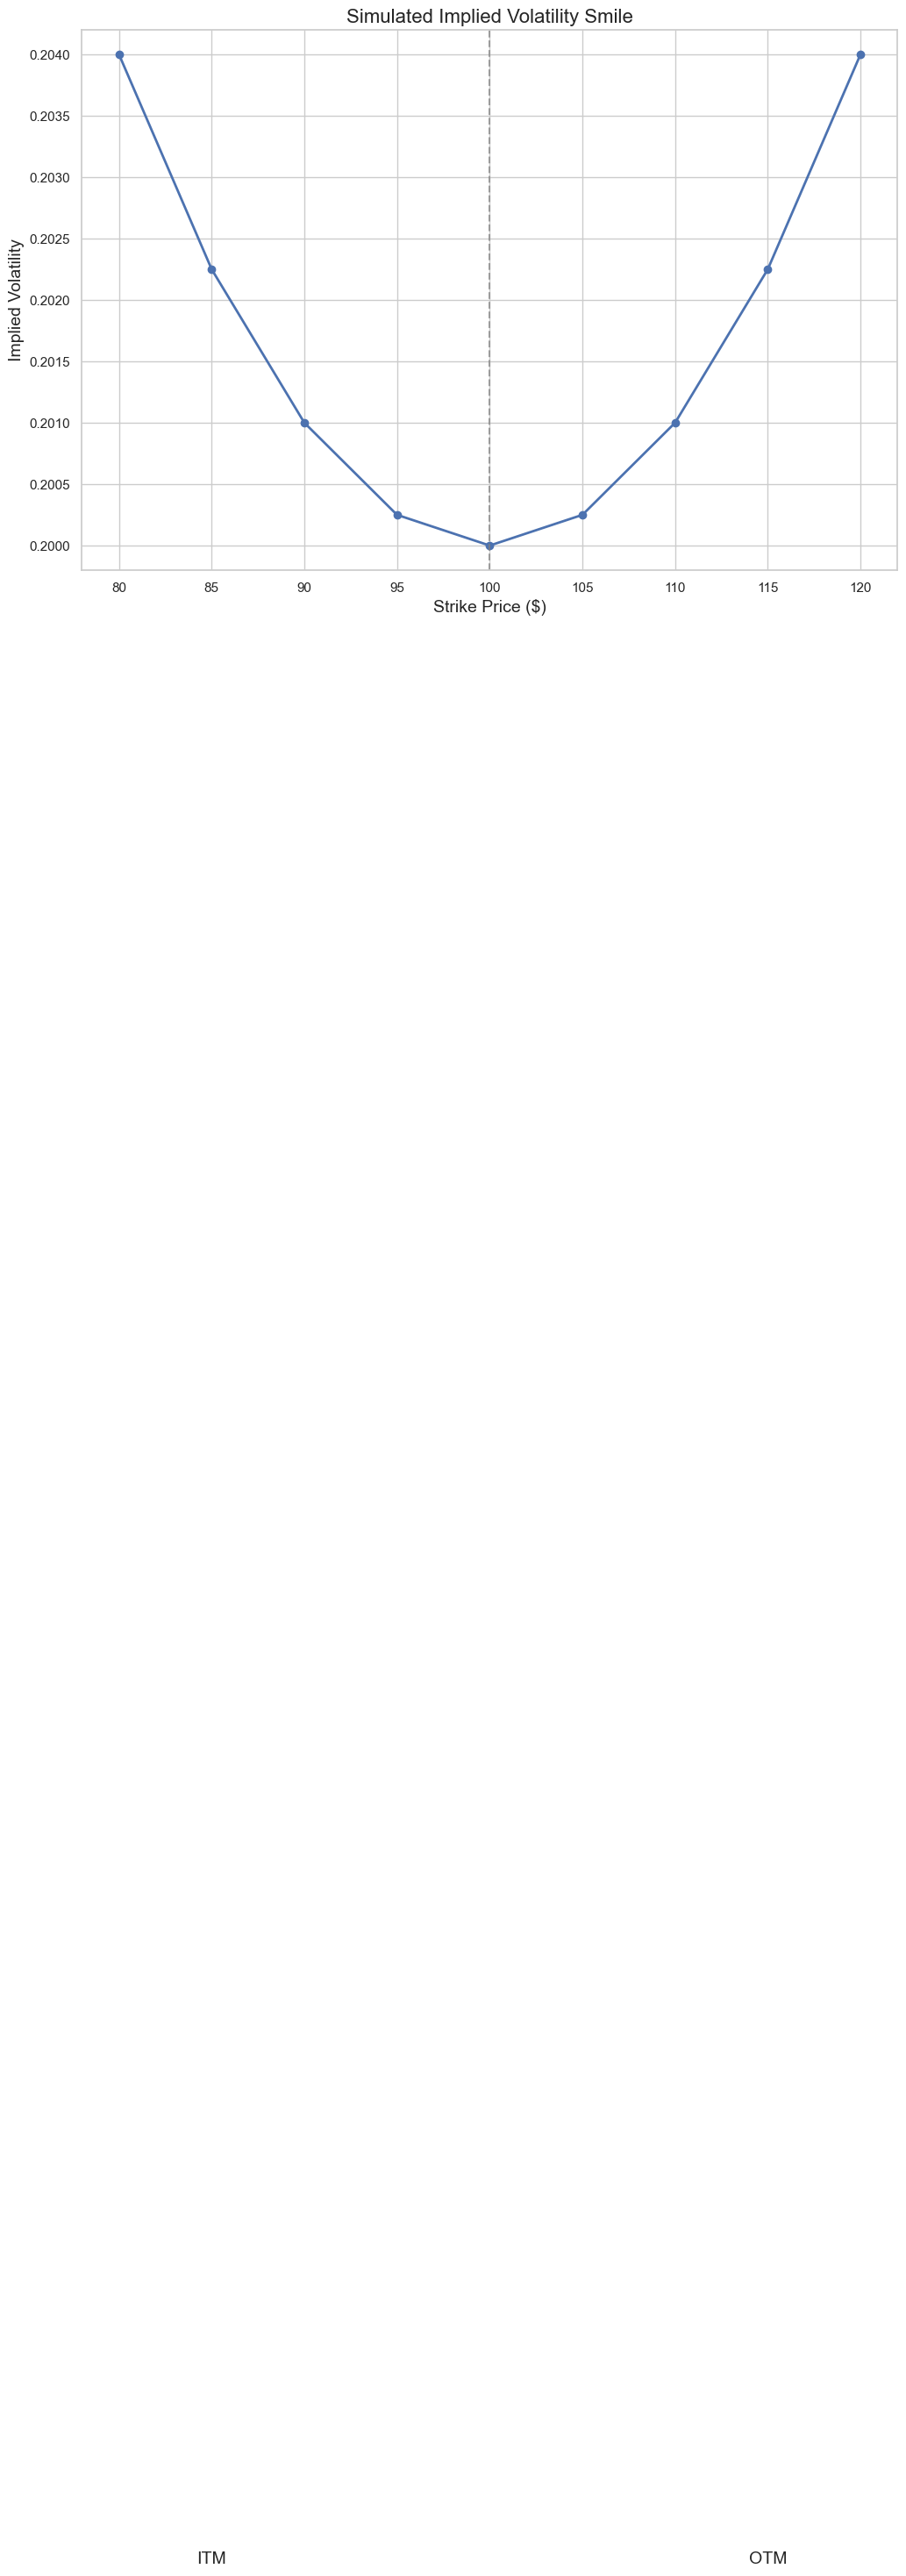

,Strike,Market Price,Implied Volatility
0,80.0,24.644348,0.20400
1,85.0,20.515239,0.20225
2,90.0,16.726651,0.20100
3,95.0,13.354764,0.20025
4,100.0,10.450584,0.20000
5,105.0,8.031270,0.20025
6,110.0,6.079668,0.20100
7,115.0,4.551133,0.20225
8,120.0,3.384346,0.20400


In [16]:
# Generate strikes around the current price
strikes = np.linspace(80, 120, 9)

# Create simulated market prices with a volatility smile effect
base_vol = 0.20
implied_vols = np.array([base_vol + 0.10*((K_i/S - 1)**2) for K_i in strikes])
market_prices = [black_scholes_price(S, K_i, T, r, sigma_i, 'call') 
                for K_i, sigma_i in zip(strikes, implied_vols)]

# Plot the simulated volatility smile
plt.figure(figsize=(12, 8))
plt.plot(strikes, implied_vols, 'o-', linewidth=2)
plt.axvline(x=S, color='gray', linestyle='--', alpha=0.7)
plt.title('Simulated Implied Volatility Smile', fontsize=16)
plt.xlabel('Strike Price ($)', fontsize=14)
plt.ylabel('Implied Volatility', fontsize=14)
plt.grid(True)
plt.text(S*0.85, max(implied_vols)*0.9, 'ITM', fontsize=14, ha='center', va='center')
plt.text(S*1.15, max(implied_vols)*0.9, 'OTM', fontsize=14, ha='center', va='center')
plt.show()

# Create a DataFrame to display strikes, prices, and implied vols
smile_df = pd.DataFrame({
    'Strike': strikes,
    'Market Price': market_prices,
    'Implied Volatility': implied_vols
})

smile_df

## Summary

In this notebook, we've demonstrated the core capabilities of our Options Pricing Simulator:

1. Black-Scholes pricing for European options
2. Binomial and Trinomial tree models for pricing American and European options
3. Options Greeks calculation and visualization
4. 3D surface plots for option prices and Greeks
5. Payoff diagrams for various option strategies
6. Implied volatility calculation and visualization

These tools provide a comprehensive framework for understanding option pricing, risk management, and strategy analysis.